# DRC Fixing Utilities

**Design Rule Check (DRC)** violations occur when shapes on a layer violate
foundry-specified constraints — most commonly:

| Violation type | Description |
|---|---|
| **Min space** | Two polygons on the same layer are closer than the allowed gap |
| **Min width** | A polygon is narrower than the process can reliably fabricate |

kfactory provides tiled utilities that detect and *automatically repair* these
violations by merging nearby shapes.  All fixers live in `kf.utils`:

| Function | Strategy | Best for |
|---|---|---|
| `kf.utils.fix_spacing_tiled` | Space-check + merge | General min-space cleanup |
| `kf.utils.fix_spacing_minkowski_tiled` | Minkowski dilation/erosion | Smoother results on complex geometry |

Both work by splitting the cell into rectangular **tiles**, processing each tile in
parallel, and collecting the corrected geometry into a new `kdb.Region`.
This keeps memory usage constant regardless of layout size.

## Setup

In [1]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WG_FIXED: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    WG_FIXED_MK: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Minimum-Space Violations

### Creating a layout with violations

We place a grid of ellipses that are intentionally too close together.
In a real PDK the minimum space rule might be 200 nm (200 dbu at 1 nm/dbu).
Here we use 1 µm (1000 dbu) as the minimum spacing so the violation is obvious.

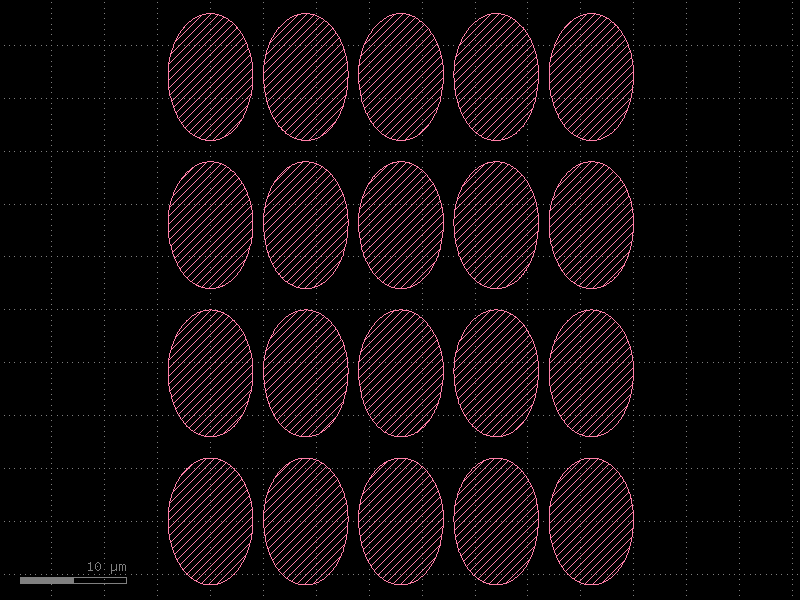

In [2]:
import kfactory.utils.fill as fill_utils

MIN_SPACE_DBU = 1000  # 1 µm minimum space rule

c = kf.KCell(name="drc_demo")

# Place ellipses in a grid — adjacent columns are only 200 nm apart (violates 1 µm rule)
for row in range(4):
    for col in range(5):
        ellipse = kf.kdb.Polygon.ellipse(kf.kdb.Box(8000, 12000), 64)
        # Offset each column by 9000 dbu — less than 8000 + 1000 spacing → violation
        c.shapes(c.kcl.layer(L.WG)).insert(
            ellipse.transformed(kf.kdb.Trans(col * 9000, row * 14000))
        )

c

### Applying `fix_spacing_tiled`

`fix_spacing_tiled` detects pairs of polygons that are closer than `min_space` and
merges them.  The function returns a `kdb.Region` with the corrected geometry.

Key parameters:
- `min_space` — minimum allowed gap in **dbu**
- `metrics` — `Euclidian` (default) or `Square`; controls how distance is measured
- `n_threads` — parallelism; `None` uses kfactory's default (CPU count)
- `tile_size` — tile dimensions in **µm**; auto-selected if `None`

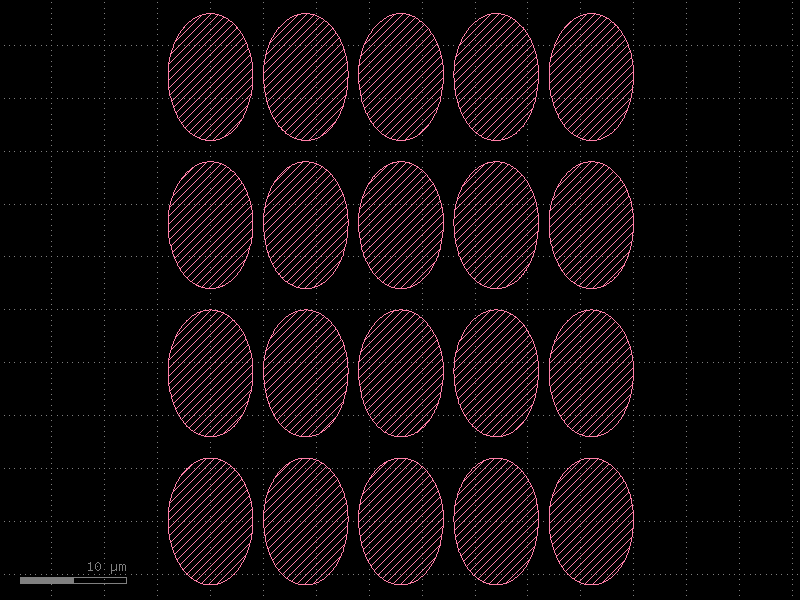

In [3]:
fixed_region = kf.utils.fix_spacing_tiled(
    c,
    MIN_SPACE_DBU,
    L.WG,
    metrics=kf.kdb.Metrics.Euclidian,
)

# Insert corrected geometry onto WG_FIXED layer so we can compare
c.shapes(c.kcl.layer(L.WG_FIXED)).insert(fixed_region)

c

**What happened:** polygons that were too close were merged into a single polygon.
The `WG` layer (layer 1) still has the original violating shapes; `WG_FIXED`
(layer 2) contains the DRC-clean result.

### Applying `fix_spacing_minkowski_tiled`

The Minkowski-sum approach dilates each polygon by `min_space/2`, merges overlapping
shapes, then erodes by the same amount.  This produces smoother, more rounded outlines
compared to the space-check approach — useful when device performance is sensitive to
sharp corners.

The optional `smooth` parameter controls how aggressively corners are simplified
after the fix (value in dbu).

2026-05-05 10:52:40.949 | INFO     | kfactory.utils.violations:fix_spacing_minkowski_tiled:272 - Starting minkowski on drc_demo


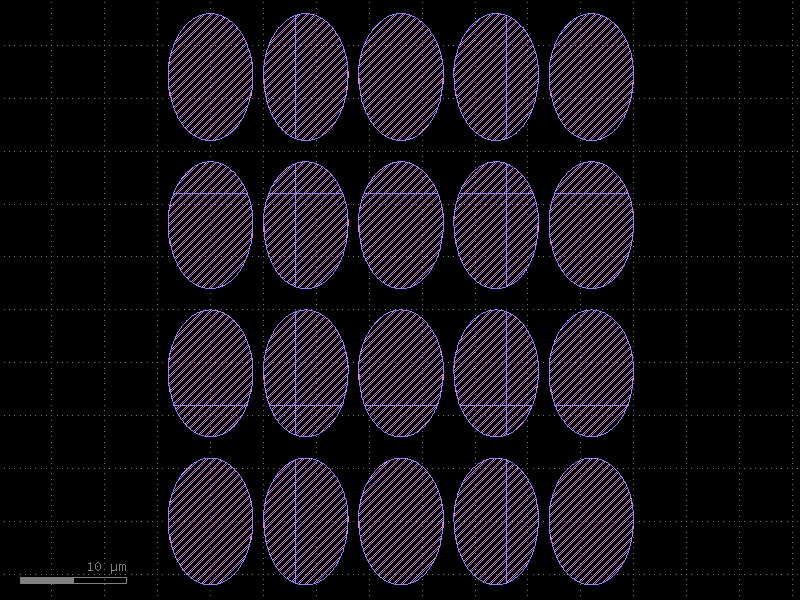

In [4]:
fixed_mk_region = kf.utils.fix_spacing_minkowski_tiled(
    c,
    MIN_SPACE_DBU,
    L.WG,
    smooth=20,
)

c.shapes(c.kcl.layer(L.WG_FIXED_MK)).insert(fixed_mk_region)

c

## 2 · Choosing the Right Fixer

| Scenario | Recommended fixer |
|---|---|
| Rectilinear (Manhattan) geometry | `fix_spacing_tiled` — faster, exact edges |
| Curved / free-form geometry | `fix_spacing_minkowski_tiled` — smoother result |
| Very large layouts (>10 mm²) | Either; both tile automatically |

## 3 · Workflow Pattern

A typical post-layout DRC fix workflow:

```python
import kfactory as kf
from kfactory.utils.violations import fix_spacing_tiled

# 1. Load or create your cell
kcl = kf.KCLayout("my_pdk")
cell = kcl["TOP"]

# 2. Run the fixer (returns a Region, does not modify in-place)
clean = kf.utils.fix_spacing_tiled(cell, min_space=200, layer=LAYER.WG)

# 3. Replace the original geometry with the fixed version
li = kcl.layer(LAYER.WG)
cell.clear(li)
cell.shapes(li).insert(clean)

# 4. Write out
kcl.write("fixed.gds")
```

> **Note:** `fix_spacing_tiled` and `fix_spacing_minkowski_tiled` return a
> `kdb.Region` — they do **not** modify the input cell in-place.  Insert the
> result where you need it, replacing or supplementing the original layer.

## 4 · Performance Notes

Both fixers use KLayout's `TilingProcessor` internally.  Tile size is auto-selected
as `max(25 × min_space_µm, 250 µm)` but can be tuned:

```python
# Larger tiles → fewer tiles, more memory per tile
kf.utils.fix_spacing_tiled(c, 200, LAYER.WG, tile_size=(500, 500))

# Smaller tiles → lower peak memory, more parallelism benefit
kf.utils.fix_spacing_tiled(c, 200, LAYER.WG, tile_size=(50, 50))
```

Thread count defaults to `kf.config.n_threads` (≈ logical CPU count).
Override with `n_threads=N` when running in a resource-constrained environment.

## See Also

| Topic | Where |
|-------|-------|
| Boolean / region operations | [Core Concepts: Geometry](../concepts/geometry.py) |
| Tile-based fill | [Utilities: Fill](fill.py) |
| Cell-level enclosures | [Enclosures: KCell Enclosure](../enclosures/kcell_enclosure.py) |
| Layout regression testing | [Utilities: Difftest](difftest.py) |